# Expanding Window — Random Intercept Worker Effects (OE & OF)

Replicates `diff_size_testing_xgboost.ipynb` but for the random intercept + worker effect model.

**Key difference from the fixed-split chunk notebooks:**  
Uses an **expanding window** (train on days 1→n, test on day n+1) so we can see how
model performance evolves as more training data accumulates — and whether the worker
effect remains useful across different training set sizes.

**The mixed model is refit on each expanding training window** to avoid leakage —
worker effects are always estimated from training data only.

**Two scenarios compared per split:**
1. `XGBoost (baseline)` — no worker features, no distance
2. `XGBoost (+ worker)` — worker_effect added, no distance

**Both warehouses: OE and OF**

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from feature_engineer import get_engineered_df

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PATH           = Path("/Users/betsyfrdmn/Lucas_Systems_Capstone_Project/data/processed")
WAREHOUSES     = ["OE", "OF"]
WORKCODES      = ["10", "20", "30"]
MAX_TIME       = 300
MIN_TRAIN_DAYS = 3   # minimum days before first test split
BLOCK_SIZE     = 50
RANDOM_STATE   = 2026

## Helper Functions

In [5]:
def load_engineered_data(warehouse, workcode, max_time=300):
    d, features_all, cat_cols_all = get_engineered_df(
        file_path=PATH / f"{warehouse.lower()}_detailed.parquet",
        warehouse=warehouse,
        max_time=max_time,
        work_code=str(workcode)
    )
    d = d.copy()
    d["Timestamp"] = pd.to_datetime(d["Timestamp"], errors="coerce")
    d = d.dropna(subset=["Timestamp"]).copy()
    d["date"]     = d["Timestamp"].dt.date
    d["WorkCode"] = d["WorkCode"].astype(str).str.replace(".0", "", regex=False)

    # Strip distance features — no distance in any scenario
    distance_num = ["Travel_Distance", "log_travel_distance"]
    distance_cat = ["same_aisle", "same_location", "diff_level"]
    features = [f for f in features_all if f not in distance_num + distance_cat]
    cat_cols = [c for c in cat_cols_all if c not in distance_cat]

    return d, features, cat_cols


def make_X(train_df, test_df, features, cat_cols):
    X_train = pd.get_dummies(train_df[features], columns=cat_cols, drop_first=True)
    X_test  = pd.get_dummies(test_df[features],  columns=cat_cols, drop_first=True)
    X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
    X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(0).astype(float)
    return X_train, X_test


def make_blocks(df, block_size=50):
    """Build fixed-size consecutive chunks per (UserID, date)."""
    d = df.sort_values(["UserID", "Timestamp"]).copy()
    blocks = []
    for (uid, day), g in d.groupby(["UserID", "date"], sort=False):
        g = g.reset_index()
        for start in range(0, len(g) - block_size + 1, block_size):
            chunk = g.iloc[start:start + block_size]
            if len(chunk) == block_size:
                blocks.append({
                    "BlockID": f"{uid}_{day}_{start // block_size}",
                    "UserID":  uid,
                    "date":    day,
                    "indices": chunk["index"].tolist()
                })
    return blocks


def eval_blocks(blocks, actual_series, pred_series):
    actual_b = [actual_series.loc[b["indices"]].sum() for b in blocks]
    pred_b   = [pred_series.loc[b["indices"]].sum()   for b in blocks]
    if len(actual_b) < 2:
        return float("nan"), float("nan")
    return mean_absolute_error(actual_b, pred_b), r2_score(actual_b, pred_b)


def estimate_worker_effects(train_df):
    """
    Fits random intercept model on training data.
    Returns DataFrame [UserID, worker_effect].
    Falls back to zeros if fewer than 2 workers or convergence fails.
    """
    df_re = train_df[["UserID", "Time_Delta_sec"]].dropna().copy()
    if df_re["UserID"].nunique() < 2:
        return pd.DataFrame({"UserID": df_re["UserID"].unique(), "worker_effect": 0.0})
    try:
        result = smf.mixedlm(
            "Time_Delta_sec ~ 1", data=df_re, groups=df_re["UserID"]
        ).fit(reml=True, disp=False)
        return pd.DataFrame({
            "UserID":        list(result.random_effects.keys()),
            "worker_effect": [float(v.iloc[0]) for v in result.random_effects.values()]
        })
    except Exception:
        return pd.DataFrame({"UserID": df_re["UserID"].unique(), "worker_effect": 0.0})

## Main Loop — Expanding Window × Both Warehouses × All WorkCodes

For each split:
- Train on days 1 → n
- Fit mixed model on that training window → get `worker_effect` per worker
- Test on day n+1
- Build blocks of size `BLOCK_SIZE` from the test day
- Evaluate both scenarios at the block level

In [6]:
all_results = []

xgb_params = dict(
    n_estimators=800, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1
)

for wh in WAREHOUSES:
    for wc in WORKCODES:
        print(f"\n--- {wh} | WorkCode {wc} ---")

        df_wc, features, cat_cols = load_engineered_data(wh, wc, MAX_TIME)
        df_wc = df_wc.sort_values("Timestamp").copy()
        unique_dates = sorted(df_wc["date"].dropna().unique())

        if len(unique_dates) <= MIN_TRAIN_DAYS:
            print(f"  Skipping — not enough dates ({len(unique_dates)})")
            continue

        cats_clean  = [c for c in cat_cols  if c != "efficient_user"]
        feats_clean = [f for f in features  if f != "efficient_user"]

        for i in range(MIN_TRAIN_DAYS, len(unique_dates)):
            train_dates = unique_dates[:i]
            test_date   = unique_dates[i]

            train_df = df_wc[df_wc["date"].isin(train_dates)].copy()
            test_df  = df_wc[df_wc["date"] == test_date].copy()

            if len(test_df) < BLOCK_SIZE:
                # Not enough test rows to form even one block — skip
                continue

            # --------------------------------------------------
            # Fit mixed model on this training window
            # --------------------------------------------------
            worker_effects = estimate_worker_effects(train_df)

            train_df = train_df.merge(worker_effects, on="UserID", how="left")
            test_df  = test_df.merge(worker_effects,  on="UserID", how="left")
            train_df["worker_effect"] = train_df["worker_effect"].fillna(0.0)
            test_df["worker_effect"]  = test_df["worker_effect"].fillna(0.0)

            # Reset index — required for block index alignment
            train_df = train_df.reset_index(drop=True)
            test_df  = test_df.reset_index(drop=True)
            y_train  = train_df["Time_Delta_sec"].astype(float)
            y_test   = test_df["Time_Delta_sec"].astype(float)

            # --------------------------------------------------
            # Build blocks from test day
            # --------------------------------------------------
            blocks = make_blocks(test_df, block_size=BLOCK_SIZE)
            if len(blocks) == 0:
                continue

            # --------------------------------------------------
            # Train and evaluate both scenarios
            # --------------------------------------------------
            scenarios = {
                "XGBoost (baseline)": feats_clean,
                "XGBoost (+ worker)": feats_clean + ["worker_effect"],
            }

            for label, feats in scenarios.items():
                X_train, X_test = make_X(train_df, test_df, feats, cats_clean)
                model = XGBRegressor(**xgb_params)
                model.fit(X_train, y_train)
                preds = pd.Series(model.predict(X_test), index=test_df.index)

                block_mae, block_r2 = eval_blocks(blocks, y_test, preds)

                all_results.append({
                    "Warehouse":       wh,
                    "WorkCode":        wc,
                    "Scenario":        label,
                    "Train_End_Date":  train_dates[-1],
                    "Test_Date":       test_date,
                    "Train_Days":      len(train_dates),
                    "Train_Rows":      len(train_df),
                    "Test_Rows":       len(test_df),
                    "N_Blocks":        len(blocks),
                    "Block_MAE":       round(block_mae, 2) if not np.isnan(block_mae) else None,
                    "MAE_per_task":    round(block_mae / BLOCK_SIZE, 3) if not np.isnan(block_mae) else None,
                    "Block_R2":        round(block_r2, 4) if not np.isnan(block_r2) else None,
                })

            print(f"  Split {i - MIN_TRAIN_DAYS + 1}: "
                  f"train through {train_dates[-1]} | test {test_date} | "
                  f"{len(blocks)} blocks")

results_df = pd.DataFrame(all_results)
print("\nDone.")


--- OE | WorkCode 10 ---
  Split 1: train through 2025-11-10 | test 2025-11-11 | 6 blocks
  Split 2: train through 2025-11-11 | test 2025-11-12 | 7 blocks
  Split 3: train through 2025-11-12 | test 2025-11-13 | 6 blocks


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


  Split 4: train through 2025-11-13 | test 2025-12-01 | 8 blocks
  Split 5: train through 2025-12-01 | test 2025-12-02 | 6 blocks

--- OE | WorkCode 20 ---
  Split 1: train through 2025-11-10 | test 2025-11-11 | 36 blocks
  Split 2: train through 2025-11-11 | test 2025-11-12 | 39 blocks
  Split 3: train through 2025-11-12 | test 2025-11-13 | 41 blocks


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


  Split 4: train through 2025-11-13 | test 2025-12-01 | 52 blocks


...

  Split 5: train through 2025-12-01 | test 2025-12-02 | 55 blocks

--- OE | WorkCode 30 ---
  Split 1: train through 2025-11-10 | test 2025-11-11 | 119 blocks
  Split 2: train through 2025-11-11 | test 2025-11-12 | 131 blocks
  Split 3: train through 2025-11-12 | test 2025-11-13 | 152 blocks
  Split 4: train through 2025-11-13 | test 2025-12-01 | 204 blocks
  Split 5: train through 2025-12-01 | test 2025-12-02 | 123 blocks

--- OF | WorkCode 10 ---
  Split 1: train through 2025-09-08 | test 2025-09-09 | 6 blocks
  Split 2: train through 2025-09-09 | test 2025-11-10 | 11 blocks
  Split 3: train through 2025-11-10 | test 2025-11-11 | 9 blocks
  Split 4: train through 2025-11-11 | test 2025-11-12 | 7 blocks
  Split 5: train through 2025-11-12 | test 2025-11-13 | 12 blocks
  Split 6: train through 2025-11-13 | test 2025-12-01 | 6 blocks


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


  Split 7: train through 2025-12-01 | test 2025-12-02 | 7 blocks

--- OF | WorkCode 20 ---
  Split 1: train through 2025-09-09 | test 2025-11-10 | 95 blocks
  Split 2: train through 2025-11-10 | test 2025-11-11 | 80 blocks
  Split 3: train through 2025-11-11 | test 2025-11-12 | 79 blocks
  Split 4: train through 2025-11-12 | test 2025-11-13 | 88 blocks
  Split 5: train through 2025-11-13 | test 2025-11-30 | 14 blocks
  Split 6: train through 2025-11-30 | test 2025-12-01 | 105 blocks
  Split 7: train through 2025-12-01 | test 2025-12-02 | 79 blocks
  Split 8: train through 2025-12-02 | test 2025-12-03 | 6 blocks

--- OF | WorkCode 30 ---
  Split 1: train through 2025-09-09 | test 2025-11-10 | 186 blocks
  Split 2: train through 2025-11-10 | test 2025-11-11 | 153 blocks


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


  Split 3: train through 2025-11-11 | test 2025-11-12 | 155 blocks
  Split 4: train through 2025-11-12 | test 2025-11-13 | 154 blocks
  Split 5: train through 2025-11-13 | test 2025-11-30 | 45 blocks
  Split 6: train through 2025-11-30 | test 2025-12-01 | 186 blocks
  Split 7: train through 2025-12-01 | test 2025-12-02 | 149 blocks

Done.


## Results Table

In [7]:
pd.set_option("display.max_rows", None)
display(results_df)

,Warehouse,WorkCode,Scenario,Train_End_Date,Test_Date,Train_Days,Train_Rows,Test_Rows,N_Blocks,Block_MAE,MAE_per_task,Block_R2
0,OE,10,XGBoost (baseline),2025-11-10,2025-11-11,3,1625,563,6,982.88,19.658,0.0203
1,OE,10,XGBoost (+ worker),2025-11-10,2025-11-11,3,1625,563,6,858.62,17.172,0.0751
2,OE,10,XGBoost (baseline),2025-11-11,2025-11-12,4,2188,483,7,901.66,18.033,-2.0660
3,OE,10,XGBoost (+ worker),2025-11-11,2025-11-12,4,2188,483,7,452.44,9.049,0.0604
4,OE,10,XGBoost (baseline),2025-11-12,2025-11-13,5,2671,427,6,443.22,8.864,-0.0192
5,OE,10,XGBoost (+ worker),2025-11-12,2025-11-13,5,2671,427,6,352.76,7.055,0.2000
6,OE,10,XGBoost (baseline),2025-11-13,2025-12-01,6,3098,501,8,603.70,12.074,0.0478
7,OE,10,XGBoost (+ worker),2025-11-13,2025-12-01,6,3098,501,8,577.23,11.545,0.5024
8,OE,10,XGBoost (baseline),2025-12-01,2025-12-02,7,3599,483,6,1004.37,20.087,-0.8516
9,OE,10,XGBoost (+ worker),2025-12-01,2025-12-02,7,3599,483,6,524.46,10.489,0.4462


## Average Performance Summary — Baseline vs + Worker

In [8]:
summary = (
    results_df
    .groupby(["Warehouse", "WorkCode", "Scenario"])[["MAE_per_task", "Block_R2"]]
    .mean()
    .round(3)
    .reset_index()
)
display(summary)

# Head-to-head improvement
rows = []
for wh in WAREHOUSES:
    for wc in WORKCODES:
        base = summary[
            (summary["Warehouse"] == wh) &
            (summary["WorkCode"]  == wc) &
            (summary["Scenario"]  == "XGBoost (baseline)")
        ]
        enh = summary[
            (summary["Warehouse"] == wh) &
            (summary["WorkCode"]  == wc) &
            (summary["Scenario"]  == "XGBoost (+ worker)")
        ]
        if base.empty or enh.empty:
            continue
        mae_base = base["MAE_per_task"].values[0]
        mae_enh  = enh["MAE_per_task"].values[0]
        imp_s    = mae_base - mae_enh
        imp_pct  = (imp_s / mae_base) * 100 if mae_base > 0 else 0
        rows.append({
            "Warehouse":              wh,
            "WorkCode":               wc,
            "Avg MAE/task baseline":  mae_base,
            "Avg MAE/task + worker":  mae_enh,
            "Improvement (s)":        round(imp_s, 3),
            "Improvement (%)": round(imp_pct, 2),
        })

print("\n--- Head-to-Head: Worker Effect Improvement ---")
display(pd.DataFrame(rows))

,Warehouse,WorkCode,Scenario,MAE_per_task,Block_R2
0,OE,10,XGBoost (+ worker),11.062,0.257
1,OE,10,XGBoost (baseline),15.743,-0.574
2,OE,20,XGBoost (+ worker),5.646,0.724
3,OE,20,XGBoost (baseline),6.274,0.630
4,OE,30,XGBoost (+ worker),6.097,0.339
5,OE,30,XGBoost (baseline),6.590,0.327
6,OF,10,XGBoost (+ worker),6.933,0.828
7,OF,10,XGBoost (baseline),8.585,0.795
8,OF,20,XGBoost (+ worker),6.600,0.835
9,OF,20,XGBoost (baseline),6.803,0.826



--- Head-to-Head: Worker Effect Improvement ---


,Warehouse,WorkCode,Avg MAE/task baseline,Avg MAE/task + worker,Improvement (s),Improvement (%)
0,OE,10,15.743,11.062,4.681,29.73
1,OE,20,6.274,5.646,0.628,10.01
2,OE,30,6.590,6.097,0.493,7.48
3,OF,10,8.585,6.933,1.652,19.24
4,OF,20,6.803,6.600,0.203,2.98
5,OF,30,9.472,9.140,0.332,3.51


## Learning Curves — MAE/task vs Training Days

Shows whether the worker effect advantage holds or narrows as more training data accumulates.

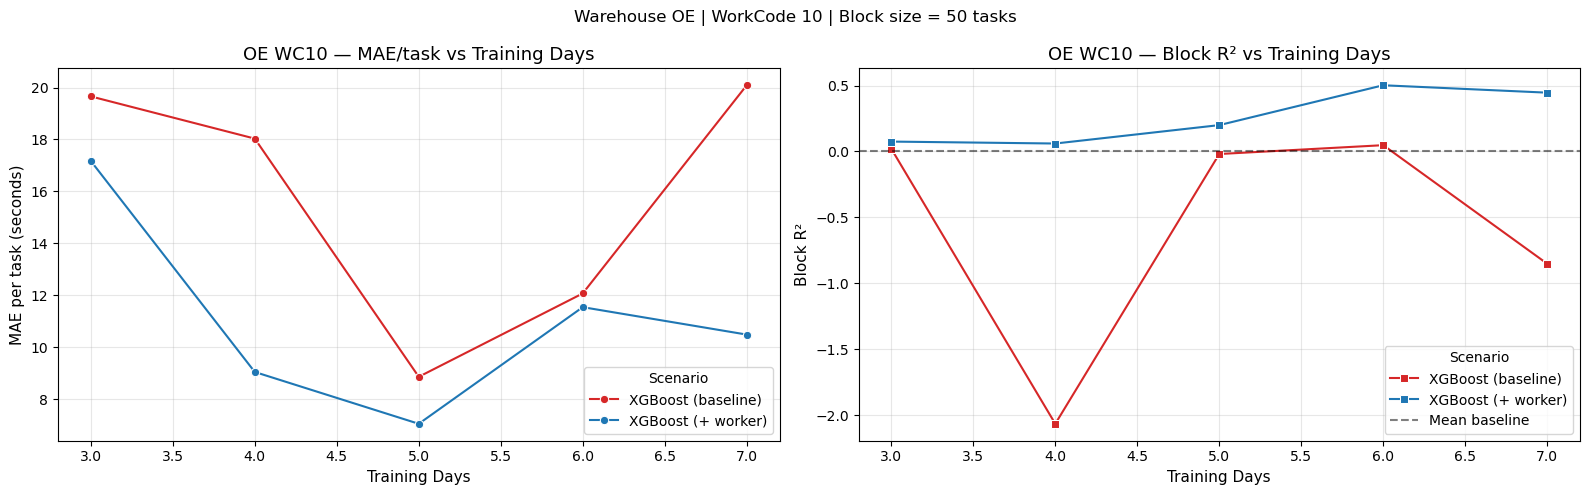

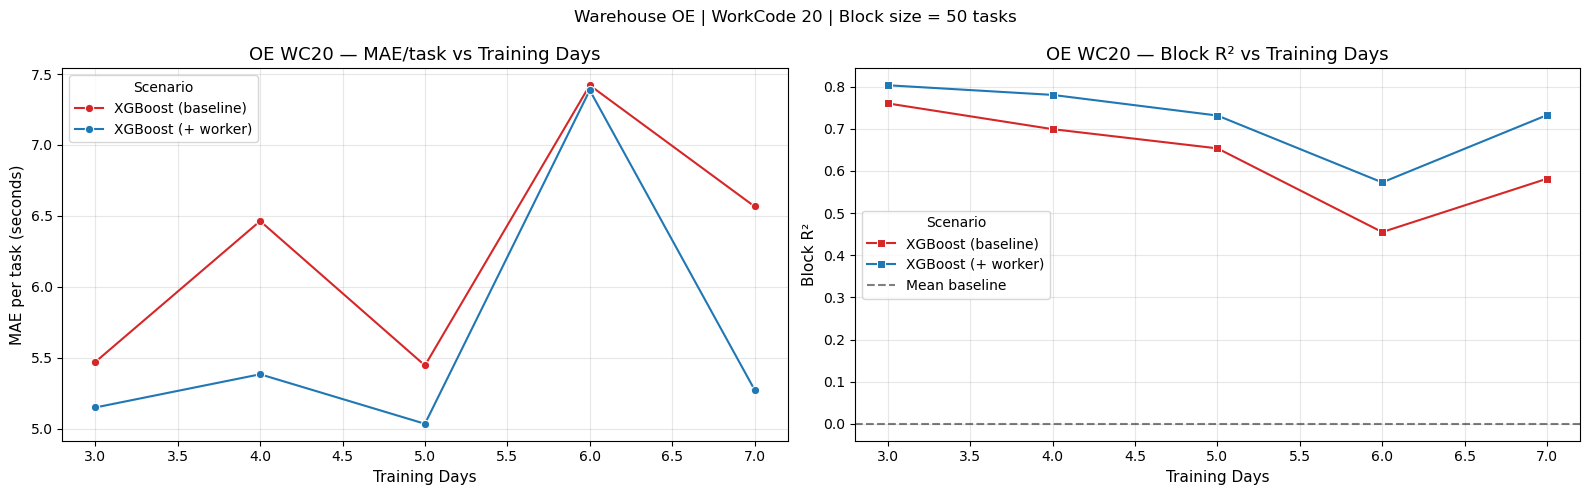

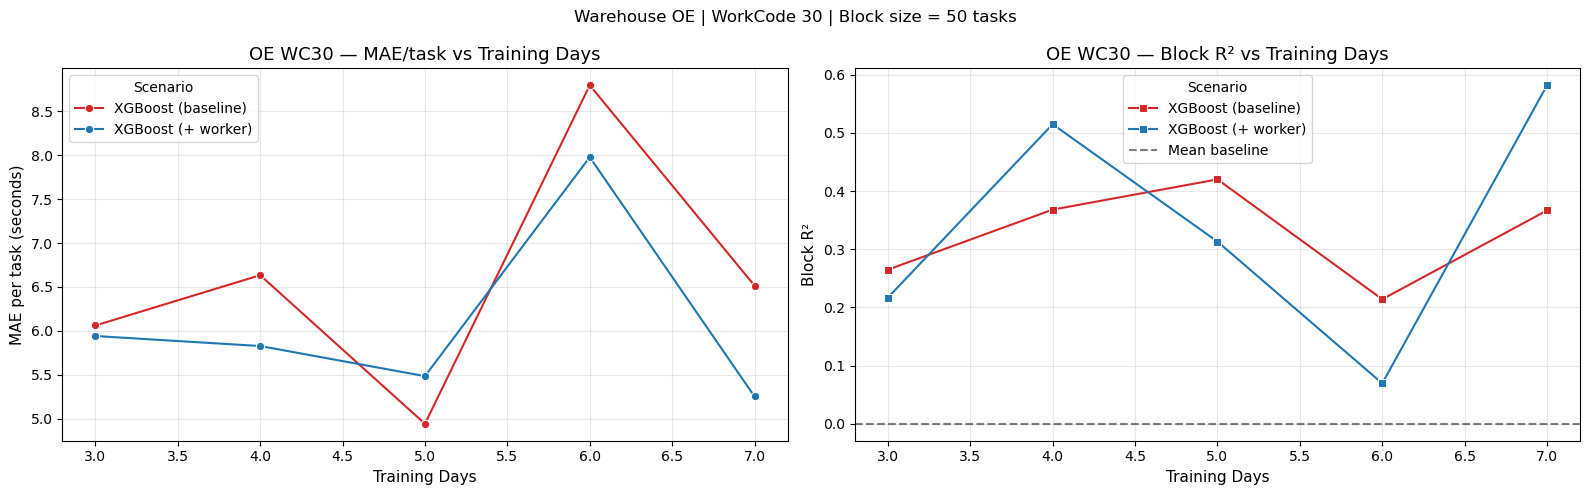

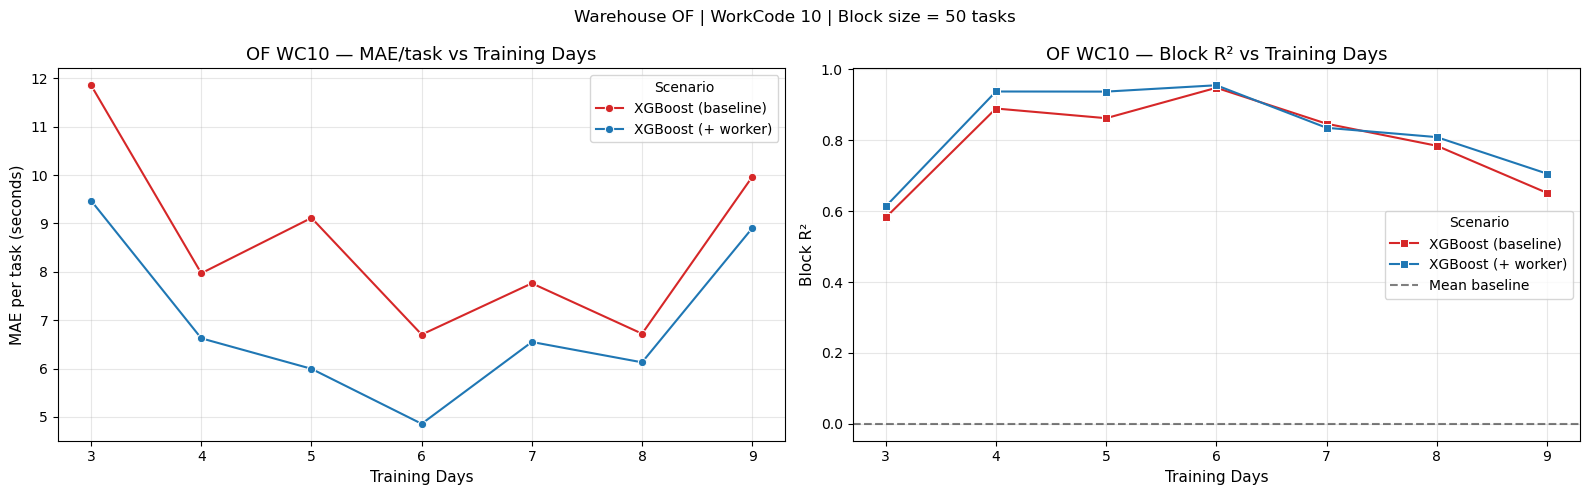

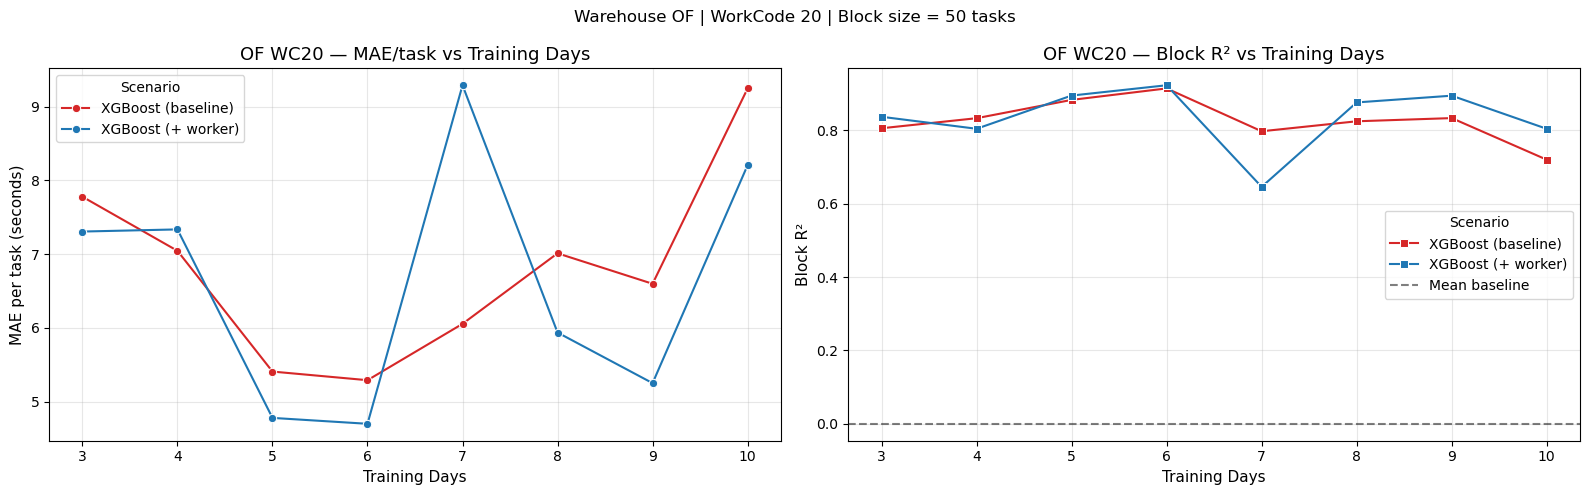

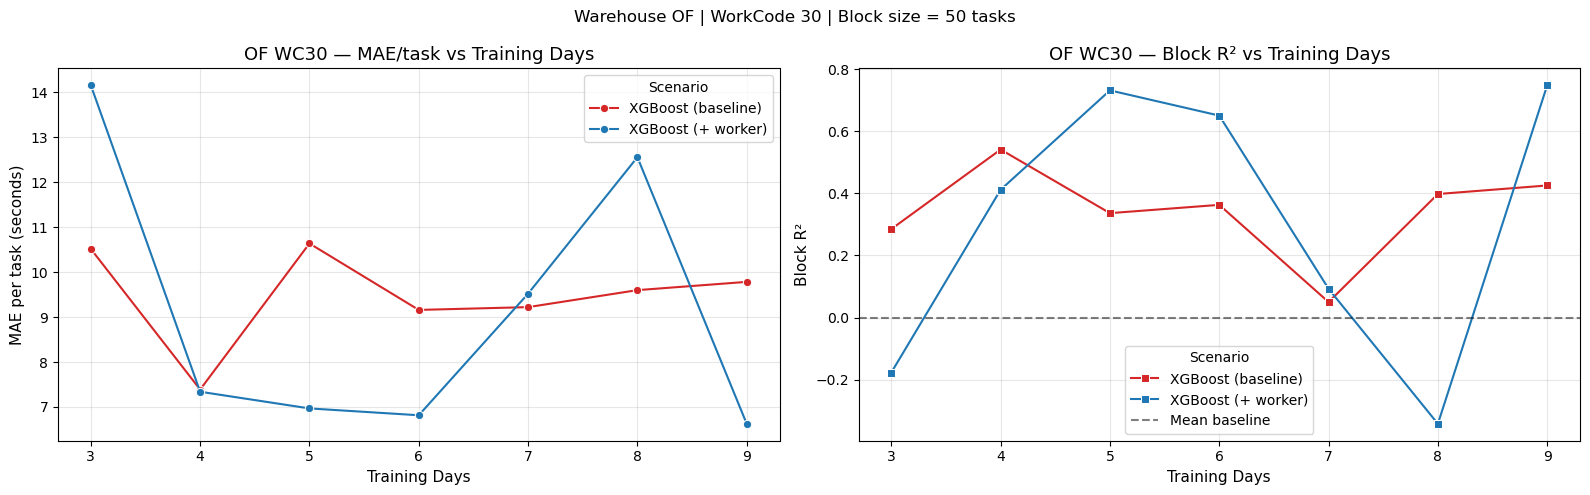

In [9]:
palette_map = {
    "XGBoost (baseline)": "tab:red",
    "XGBoost (+ worker)": "tab:blue",
}

for wh in WAREHOUSES:
    for wc in WORKCODES:
        plot_df = (
            results_df[
                (results_df["Warehouse"] == wh) &
                (results_df["WorkCode"]  == wc)
            ]
            .dropna(subset=["MAE_per_task", "Block_R2"])
            .sort_values("Train_Days")
        )

        if plot_df.empty:
            continue

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

        sns.lineplot(
            data=plot_df, x="Train_Days", y="MAE_per_task",
            hue="Scenario", marker="o", ax=ax1,
            palette=palette_map, errorbar=None
        )
        ax1.set_title(f"{wh} WC{wc} — MAE/task vs Training Days", fontsize=13)
        ax1.set_ylabel("MAE per task (seconds)", fontsize=11)
        ax1.set_xlabel("Training Days", fontsize=11)
        ax1.grid(True, alpha=0.3)
        ax1.legend(title="Scenario")

        sns.lineplot(
            data=plot_df, x="Train_Days", y="Block_R2",
            hue="Scenario", marker="s", ax=ax2,
            palette=palette_map, errorbar=None
        )
        ax2.axhline(0, color="black", linestyle="--", alpha=0.5, label="Mean baseline")
        ax2.set_title(f"{wh} WC{wc} — Block R² vs Training Days", fontsize=13)
        ax2.set_ylabel("Block R²", fontsize=11)
        ax2.set_xlabel("Training Days", fontsize=11)
        ax2.grid(True, alpha=0.3)
        ax2.legend(title="Scenario")

        plt.suptitle(
            f"Warehouse {wh} | WorkCode {wc} | Block size = {BLOCK_SIZE} tasks",
            fontsize=12
        )
        plt.tight_layout()
        plt.show()

## Save Results

In [10]:
#results_df.to_csv("expanding_window_worker_effects.csv", index=False)
#print(f"Saved {len(results_df)} rows to expanding_window_worker_effects.csv")